## 🛠️ Setup

In [4]:
%matplotlib inline

import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

# Add project root to path
import sys
sys.path.insert(0, '/Odyssey/private/m19beauc/4dvarnet-starter')
sys.path.insert(0, '/Odyssey/private/m19beauc/4dvarnet-starter/contrib/CROSCIM')

import glob
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
from cartopy.io.shapereader import Reader
cartopy.config['pre_existing_data_dir'] = os.path.abspath('../../contrib/CROSCIM/cartopy')
cartopy.config['data_dir'] = os.path.abspath('../../contrib/CROSCIM/cartopy')
print('Setup OK')


Setup OK


## 📂 Paths (from config)

In [2]:
PATHS = dict(
    src     = '/Odyssey/private/m19beauc',
    mask    = '/Odyssey/private/m19beauc/4dvarnet-starter/contrib/CROSCIM/mask_PanArctic.nc',
    asip    = '/Odyssey/public/CROSCIM_dataset/ASIP_L3',
    cimr    = '/Odyssey/public/CROSCIM_dataset/data_noise',
    cristal = '/Odyssey/public/CROSCIM_dataset/out_CRISTAL',
    covariates = '/Odyssey/public/CROSCIM_dataset/atm_data',
    models  = '/Odyssey/public/CROSCIM_dataset/out_MOD',
)

# Test period defined in the yaml
TEST_DATE = '2021-02-01'

# Preprocessed 5 km files (used by the dataloader)
asip_files    = sorted(glob.glob(PATHS['asip']    + '/*nc'))
cimr_files    = sorted(glob.glob(PATHS['cimr']    + '/CIMR5km_*nc'))
cristal_files = sorted(glob.glob(PATHS['cristal'] + '/CRISTAL5km_*nc'))
mod_files     = sorted(glob.glob(PATHS['models']  + '/MOD5km_*nc'))

print(f'ASIP files      : {len(asip_files)}')
print(f'CIMR 5km files  : {len(cimr_files)}')
print(f'CRISTAL 5km files: {len(cristal_files)}')
print(f'MOD 5km files   : {len(mod_files)}')

ASIP files      : 316
CIMR 5km files  : 316
CRISTAL 5km files: 316
MOD 5km files   : 316


---
## 1️⃣ Raw data inspection

Load one daily file from each source and display basic metadata.

In [5]:
# --- ASIP (500 m, Pan-Arctic grid) ---
asip_day = [f for f in asip_files if '20220201' in f]
print('ASIP files for', TEST_DATE, ':', asip_day)

ds_asip = xr.open_dataset(asip_day[0])
print(ds_asip)
ds_asip.close()

ASIP files for 2021-02-01 : ['/Odyssey/public/CROSCIM_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220201.nc']
<xarray.Dataset>
Dimensions:                 (time: 1, xc: 15200, yc: 22400)
Coordinates:
  * time                    (time) datetime64[ns] 2022-02-01T23:23:44
  * xc                      (xc) float64 -3.85e+06 -3.849e+06 ... 3.75e+06
  * yc                      (yc) float64 5.85e+06 5.849e+06 ... -5.35e+06
    lat                     (yc, xc) float32 ...
    lon                     (yc, xc) float32 ...
Data variables:
    crs                     float32 ...
    acq_time                (time, yc, xc) float32 ...
    sic                     (time, yc, xc) float32 ...
    sod                     (time, yc, xc) float32 ...
    flz                     (time, yc, xc) float32 ...
    standard_deviation_sic  (time, yc, xc) float32 ...
    confidence_sod          (time, yc, xc) float32 ...
    confidence_flz          (time, yc, xc) float32 ...
    status_flag             (time, yc,

In [6]:
# --- CIMR 5 km (re-gridded) ---
cimr_day = [f for f in cimr_files if '2022-02-01' in f]
print('CIMR files for', TEST_DATE, ':', cimr_day)

ds_cimr = xr.open_dataset(cimr_day[0])
print(ds_cimr)
ds_cimr.close()

CIMR files for 2021-02-01 : ['/Odyssey/public/CROSCIM_dataset/data_noise/CIMR5km_2022-02-01.nc']
<xarray.Dataset>
Dimensions:     (yc: 1475, xc: 1520, time: 1)
Coordinates:
    lat         (yc, xc) float32 ...
    lon         (yc, xc) float32 ...
  * time        (time) datetime64[ns] 2019-09-21T23:23:44
  * xc          (xc) float64 -3.85e+06 -3.845e+06 ... 3.74e+06 3.745e+06
  * yc          (yc) float64 2.474e+06 2.469e+06 ... -4.891e+06 -4.896e+06
Data variables:
    SIC         (yc, xc) float64 ...
    SIT         (yc, xc) float64 ...
    Tsurf       (yc, xc) float64 ...
    SICnoise    (yc, xc) float64 ...
    SITnoise    (yc, xc) float64 ...
    Tsurfnoise  (yc, xc) float64 ...


In [7]:
# --- CRISTAL 5 km (re-gridded) ---
cristal_day = [f for f in cristal_files if '2022-02-01' in f]
print('CRISTAL files for', TEST_DATE, ':', cristal_day)

ds_cristal = xr.open_dataset(cristal_day[0])
print(ds_cristal)
ds_cristal.close()

CRISTAL files for 2021-02-01 : ['/Odyssey/public/CROSCIM_dataset/out_CRISTAL/CRISTAL5km_no_N_2022-02-01.nc']
<xarray.Dataset>
Dimensions:    (yc: 1475, xc: 1520, time: 1)
Coordinates:
    lat        (yc, xc) float32 ...
    lon        (yc, xc) float32 ...
  * time       (time) datetime64[ns] 2019-09-21T23:23:44
  * xc         (xc) float64 -3.85e+06 -3.845e+06 ... 3.74e+06 3.745e+06
  * yc         (yc) float64 2.474e+06 2.469e+06 ... -4.891e+06 -4.896e+06
Data variables:
    HS         (yc, xc) float64 ...
    SIT        (yc, xc) float64 ...
    SSH        (yc, xc) float64 ...
    HS_model   (yc, xc) float32 ...
    SIT_model  (yc, xc) float32 ...
    SSH_model  (yc, xc) float64 ...


---
## 2️⃣ Spatial overview — one variable per source

Plot **SIC (ASIP), SIC (CIMR), SIT (CRISTAL)** and **SIT (MOD)** for the test date
on the Pan-Arctic stereographic projection.

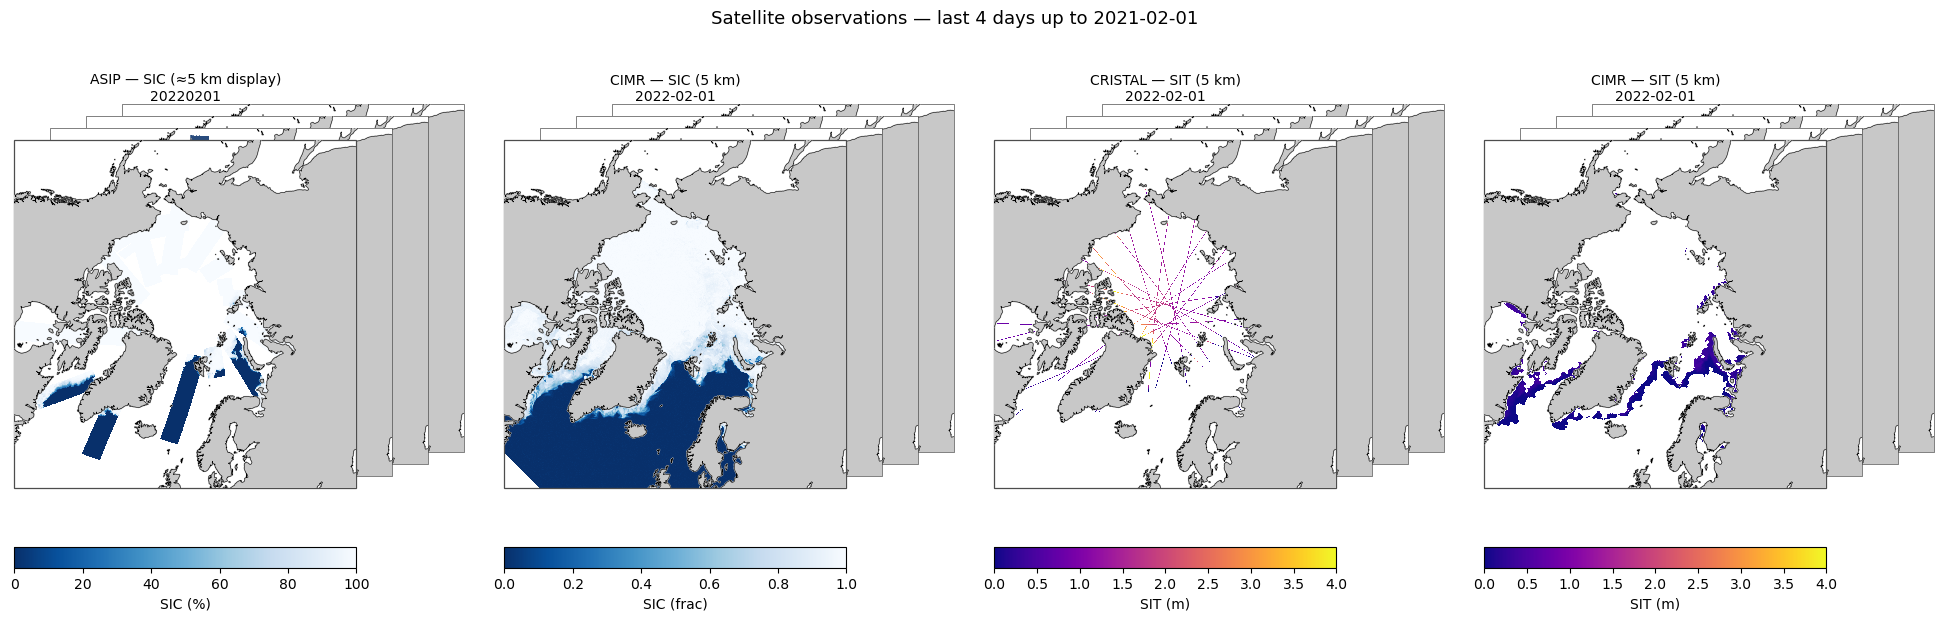

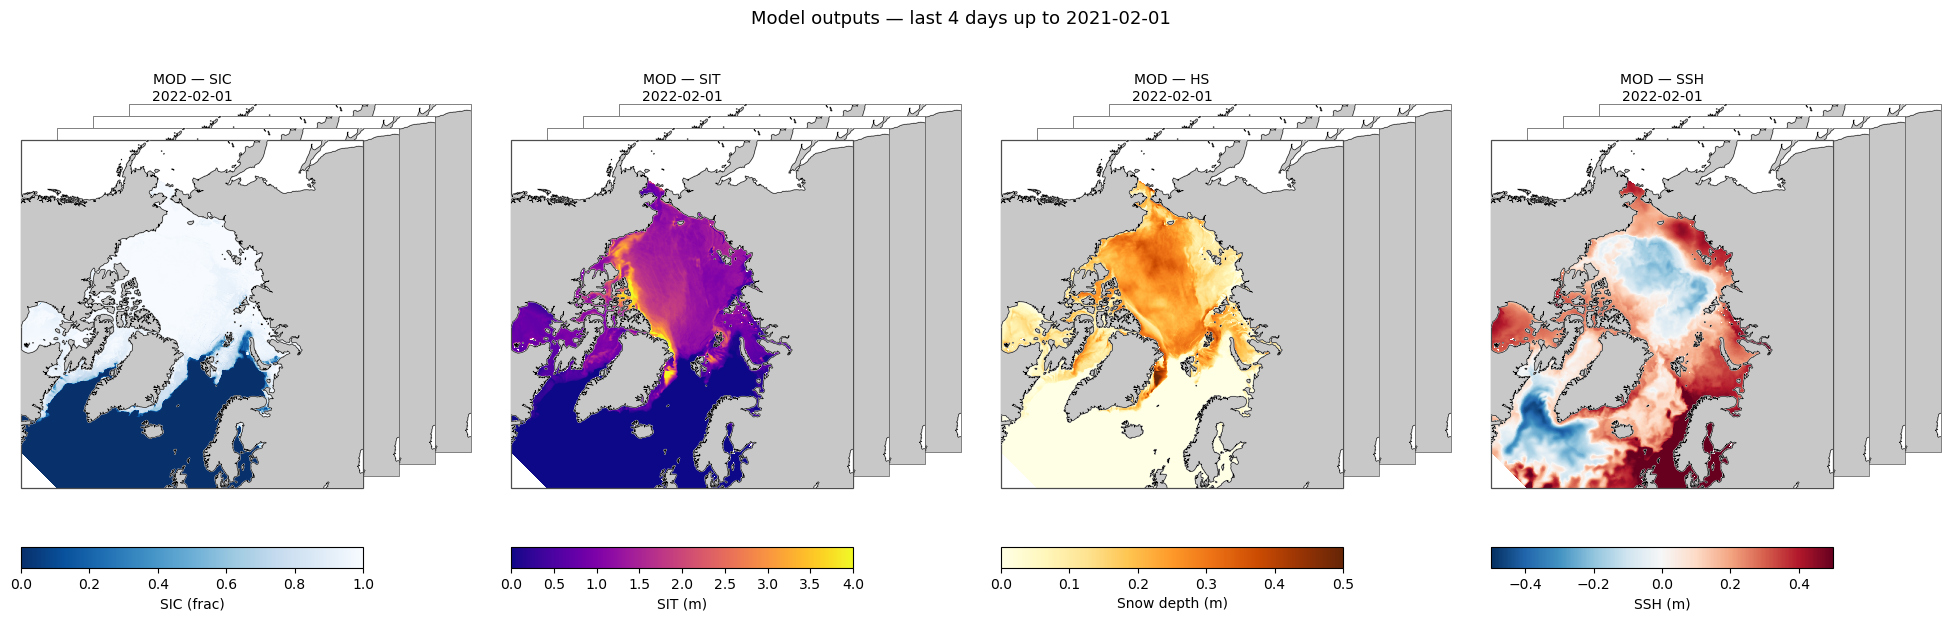

In [17]:
import warnings
warnings.filterwarnings('ignore')

import re
from dataloaders.load_data import fast_coarsen_xr

# Domain limits from yaml
DOMAIN = dict(
    xc=slice(-3_849_750., 3_749_750.),
    yc=slice( 2_473_750., -4_896_250.)
)

# Number of consecutive daily maps stacked to convey the time dimension
N_STACK = 4

# --- Common cartopy projection ---
PROJ     = ccrs.NorthPolarStereo(central_longitude=0, true_scale_latitude=70)
DATA_CRS = ccrs.NorthPolarStereo(central_longitude=0, true_scale_latitude=70)

def last_n_matching(files, date_str, n=N_STACK):
    """Return up to `n` chronologically sorted files ending at (and including)
    the one matching `date_str`, so we can show it plus a few preceding days."""
    idx = next((i for i, f in enumerate(files) if date_str in f), None)
    if idx is None:
        return []
    start = max(0, idx - (n - 1))
    return files[start: idx + 1]

def _date_label(fname):
    m = re.search(r'(\d{4}-\d{2}-\d{2})|(\d{8})', os.path.basename(fname))
    return m.group(0) if m else os.path.basename(fname)

def load_frames(files, varname, coarsen=False):
    """Open each daily file, pull one 2-D field + coords, then close it.
    Returns a list of (date_label, lon, lat, data) ordered oldest -> newest."""
    frames = []
    for f in files:
        ds = xr.open_dataset(f).sel(**DOMAIN)
        if coarsen:
            ds = fast_coarsen_xr(ds, factor_y=10, factor_x=10)
        if varname in ds:
            frames.append((_date_label(f), ds.lon.values, ds.lat.values, ds[varname].values))
        ds.close()
    return frames

def plot_stack_arctic(fig, rect, frames, cmap, vmin, vmax, title, cbar_label,
                       dx=0.018, dy=0.020):
    """Draw `frames` (oldest -> newest) as a slightly-offset cascade of maps inside
    `rect` = (left, bottom, width, height), fig-fraction coords, to convey the time
    dimension. Older frames sit further back (offset up/right) and are faded; the
    most recent frame is drawn last, on top, fully opaque. Only that front map gets
    a horizontal colorbar, placed directly underneath it."""
    left, bottom, width, height = rect

    if not frames:
        ax = fig.add_axes([left, bottom, width, height], projection=PROJ)
        ax.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, zorder=5, color='#c8c8c8')
        ax.coastlines(resolution='50m', linewidth=0.5, zorder=6)
        ax.set_title(f'{title} (not available)', fontsize=10)
        return None

    n = len(frames)
    cbar_h  = 0.035
    cbar_pad = 0.03
    map_bottom = bottom + cbar_h + cbar_pad
    map_h      = height - cbar_h - cbar_pad
    card_w = width  - (n - 1) * dx
    card_h = map_h  - (n - 1) * dy

    pcm_front = None
    for i, (label, lon, lat, data) in enumerate(frames):
        back_i = n - 1 - i  # 0 = frontmost/most recent, larger = further back in time
        off_x, off_y = back_i * dx, back_i * dy
        ax = fig.add_axes(
            [left + off_x, map_bottom + off_y, card_w, card_h],
            projection=PROJ, zorder=10 + i
        )
        ax.set_facecolor('white')
        ax.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
        alpha = 1.0 if back_i == 0 else max(0.35, 0.85 - 0.22 * back_i)
        pcm = ax.pcolormesh(
            lon, lat, np.squeeze(data),
            transform=ccrs.PlateCarree(),
            cmap=cmap, vmin=vmin, vmax=vmax,
            shading='auto', rasterized=True, alpha=alpha
        )
        ax.add_feature(cfeature.LAND, zorder=5, color='#c8c8c8')
        ax.coastlines(resolution='50m', linewidth=0.4, zorder=6)
        for spine in ax.spines.values():
            spine.set_edgecolor('0.3')
            spine.set_linewidth(0.9 if back_i == 0 else 0.5)
        if back_i == 0:
            ax.set_title(f'{title}\n{label}', fontsize=10, y=1.09)
            pcm_front = pcm

    cax = fig.add_axes([left, bottom, card_w, cbar_h])
    fig.colorbar(pcm_front, cax=cax, orientation='horizontal', label=cbar_label)
    return pcm_front

def stacked_row(fig, panels):
    """panels: list of dicts with keys frames, cmap, vmin, vmax, title, cbar_label,
    laid out as evenly spaced columns across the figure."""
    n = len(panels)
    left_m, right_m, gap = 0.03, 0.99, 0.02
    top_m, bottom_m = 0.90, 0.06
    col_w = (right_m - left_m - (n - 1) * gap) / n
    for i, p in enumerate(panels):
        rect = (left_m + i * (col_w + gap), bottom_m, col_w, top_m - bottom_m)
        plot_stack_arctic(fig, rect, p['frames'], p['cmap'], p['vmin'], p['vmax'],
                           p['title'], p['cbar_label'])

# --- Gather a short time stack (oldest -> newest = TEST_DATE) per source ---
asip_stack_files    = last_n_matching(asip_files,    '20220201')
cimr_stack_files    = last_n_matching(cimr_files,    '2022-02-01')
cristal_stack_files = last_n_matching(cristal_files, '2022-02-01')
mod_stack_files     = last_n_matching(mod_files,     '2022-02-01')

asip_sic_frames    = load_frames(asip_stack_files,    'sic', coarsen=True)
cimr_sic_frames    = load_frames(cimr_stack_files,    'SIC')
cimr_sit_frames    = load_frames(cimr_stack_files,    'SIT')
cristal_sit_frames = load_frames(cristal_stack_files, 'SIT')

# ── Row 1: satellite observations (SIC/SIT stacks show the time dimension) ──
fig = plt.figure(figsize=(20, 6))
stacked_row(fig, [
    dict(frames=asip_sic_frames,    cmap='Blues_r', vmin=0, vmax=100, title='ASIP — SIC (≈5 km display)', cbar_label='SIC (%)'), 
    dict(frames=cimr_sic_frames,    cmap='Blues_r', vmin=0, vmax=1,   title='CIMR — SIC (5 km)',          cbar_label='SIC (frac)'),
    dict(frames=cristal_sit_frames, cmap='plasma',  vmin=0, vmax=4,   title='CRISTAL — SIT (5 km)',       cbar_label='SIT (m)'),
    dict(frames=cimr_sit_frames,    cmap='plasma',  vmin=0, vmax=4,   title='CIMR — SIT (5 km)',          cbar_label='SIT (m)'),
])
fig.suptitle(f'Satellite observations — last {N_STACK} days up to {TEST_DATE}', fontsize=13, y=0.99)
plt.show()

# ── Row 2: model outputs (SIC, SIT, Snow Depth, SSH) ─────────────────────────
MOD_VARS = [
    ('SIC', 'Blues_r', 'SIC (frac)',     0,    1   ),
    ('SIT', 'plasma',  'SIT (m)',        0,    4   ),
    ('HS',  'YlOrBr',  'Snow depth (m)', 0,    0.5 ),
    ('SSH', 'RdBu_r',  'SSH (m)',       -0.5,  0.5 ),
]

fig2 = plt.figure(figsize=(20, 6))
stacked_row(fig2, [
    dict(frames=load_frames(mod_stack_files, var), cmap=cmap, vmin=vmin, vmax=vmax,
         title=f'MOD — {var}', cbar_label=label)
    for var, cmap, label, vmin, vmax in MOD_VARS
])
fig2.suptitle(f'Model outputs — last {N_STACK} days up to {TEST_DATE}', fontsize=13, y=0.99)
plt.show()

---
## 3️⃣ DataModule — `BaseDataModuleMultiRes`

Instantiate the multi-resolution DataModule using the variable configuration
from the yaml.  
We **do not call `setup()`** here — that would trigger full data loading.  
Instead we just instantiate and call `setup('test')` to build the test datasets.

In [7]:
from contrib.CROSCIM.load_data import get_paths_for_source
from contrib.CROSCIM.dataloaders.data_multires_supervised import BaseDataModuleMultiRes

# ---- Variable config (mirrors the yaml) ----
SATELLITE_VARS = {
    'cristal': ['SIT'],
    'cimr':    ['SIT', 'SIC'],
    'asip':    ['sic'],
}
MODELS_VARS  = ['SIT', 'SIC']
COVARIATES   = ['t2m', 'msl', 'u10', 'v10']

TARGET_VARS = {
    'patch_x50': ['models_SIT', 'models_SIC'],
    'patch_x10': ['models_SIT', 'models_SIC'],
    'patch_x2':  ['models_SIT', 'tgt_SIC'],
}
VAR_MAPPING = {
    'patch_x50': {'models_SIT': 'cristal_SIT', 'models_SIC': 'cimr_SIC'},
    'patch_x10': {'models_SIT': 'cristal_SIT', 'models_SIC': 'cimr_SIC'},
    'patch_x2':  {'models_SIT': 'cristal_SIT', 'tgt_SIC':    'asip_sic'},
}

NORM_STATS = {
    'asip':    {'sic': {'min': 0.0,   'max': 100.0, 'type': 'minmax'}},
    'cimr':    {'SIC': {'min': 0.0,   'max': 1.0,   'type': 'minmax'},
                'SIT': {'mean': 0.5696, 'std': 0.8216, 'type': 'zscore'}},
    'cristal': {'SIT': {'mean': 0.5696, 'std': 0.8216, 'type': 'zscore'}},
}
NORM_STATS_MODELS = {
    'SIC': {'min': 0.0,   'max': 1.0,   'type': 'minmax'},
    'SIT': {'mean': 0.5696, 'std': 0.8216, 'type': 'zscore'},
}
NORM_STATS_COVS = {
    'msl': {'mean': 101261.7, 'std': 1112.7, 'type': 'zscore'},
    't2m': {'mean': -2.6,     'std': 13.6,   'type': 'zscore'},
    'u10': {'mean':  0.6,     'std':  4.5,   'type': 'zscore'},
    'v10': {'mean': -0.21,    'std':  4.7,   'type': 'zscore'},
}

# ---- XRDS keyword args (mirrors the yaml) ----
XRDS_KW = dict(
    patch_dims       = {'time': 15, 'yc': 256, 'xc': 256},
    strides          = {'time': 1,  'yc': 28,  'xc': 28},
    strides_test     = {'time': 1,  'yc': 200, 'xc': 200},
    patch_dims_dict  = {
        50: {'time': 15, 'yc': 294, 'xc': 304},
        10: {'time': 15, 'yc': 256, 'xc': 256},
        2:  {'time': 15, 'yc': 256, 'xc': 256},
    },
    strides_test_dict = {
        50: {'time': 1, 'yc': 294, 'xc': 304},
        10: {'time': 1, 'yc': 200, 'xc': 200},
        2:  {'time': 1, 'yc': 200, 'xc': 200},
    },
    domain_limits = {
        'xc': slice(-3_849_750., 3_749_750.),
        'yc': slice( 2_473_750., -4_896_250.),
    },
)

# ---- Domain slices (test period) ----
from omegaconf import OmegaConf
DOMAINS = {
    'train': {'time': slice('2022-05-01', '2022-12-31')},
    'val':   {'time': [slice('2022-05-01', '2022-06-30'), slice('2022-07-01', '2022-12-31')]},
    'test':  {'time': slice('2021-02-01', '2021-02-15')},
}

mask = xr.open_dataset(PATHS['mask'])['mask'].sel(**XRDS_KW['domain_limits'])

dm = BaseDataModuleMultiRes(
    asip_paths       = get_paths_for_source('asip',       PATHS),
    cimr_paths       = get_paths_for_source('cimr',       PATHS),
    cristal_paths    = get_paths_for_source('cristal',    PATHS),
    covariates_paths = get_paths_for_source('covariates', PATHS),
    models_paths     = get_paths_for_source('models',     PATHS),
    satellite_vars   = SATELLITE_VARS,
    models_vars      = MODELS_VARS,
    covariates       = COVARIATES,
    target_vars      = TARGET_VARS,
    var_mapping      = VAR_MAPPING,
    multires         = [50, 10, 2],
    mask_path        = PATHS['mask'],
    domain_name      = 'arctic_croscim',
    domains          = DOMAINS,
    xrds_kw          = XRDS_KW,
    dl_kw            = {'batch_size': 1, 'num_workers': 0},
    res              = 500,
    pads             = [False, False, True],
    norm_stats       = NORM_STATS,
    norm_stats_models= NORM_STATS_MODELS,
    norm_stats_covs  = NORM_STATS_COVS,
)
print('DataModule instantiated ✅')

TrainingItem fields: ('cristal_SIT', 'cimr_SIT', 'cimr_SIC', 'asip_sic', 'models_SIT', 'models_SIC', 'patch_x50', 'patch_x10', 'patch_x2', 'tgt_SIT', 'tgt_SIC', 't2m', 'msl', 'u10', 'v10', 'lat', 'lon', 'land_mask', 'time', 'yc', 'xc')

BaseDataModule configuration:
  Satellite vars: {'cristal': ['SIT'], 'cimr': ['SIT', 'SIC'], 'asip': ['sic']}
  Active sources: ['cristal', 'cimr', 'asip']
  Covariates: ['t2m', 'msl', 'u10', 'v10']
  Target vars: {'patch_x50': ['models_SIT', 'models_SIC'], 'patch_x10': ['models_SIT', 'models_SIC'], 'patch_x2': ['models_SIT', 'tgt_SIC']}
  Var mapping: {'patch_x50': {'models_SIT': 'cristal_SIT', 'models_SIC': 'cimr_SIC'}, 'patch_x10': {'models_SIT': 'cristal_SIT', 'models_SIC': 'cimr_SIC'}, 'patch_x2': {'models_SIT': 'cristal_SIT', 'tgt_SIC': 'asip_sic'}}

TrainingItem fields: ('cristal_SIT', 'cimr_SIT', 'cimr_SIC', 'asip_sic', 'models_SIT', 'models_SIC', 'tgt_SIC', 'tgt_SIT', 't2m', 'msl', 'u10', 'v10', 'lat', 'lon', 'land_mask', 'time', 'yc', 'xc')

B

In [11]:
# Setup test split (loads test data into memory)
dm.setup('test')
print('Test dataset sizes:')
for res, ds in dm.test_ds.datasets.items():
    print(f'  x{res}: {len(ds)} patches')


XrDatasetMultiResTest configuration:
  Multires: [50, 10, 2]
  Resolution x50:
    patch_dims: time=15, yc=294, xc=304
Coarsening target data by factor 50
Loading cristal data for variables: ['SIT']
None
Loading cristal data for variables: ['SIT']
None


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Batch computation too fast (0.12531447410583496s.) Setting batch_size=2.
[Parallel(n_jobs=15)]: Done   3 out of  14 | elapsed:    0.2s remaining:    0.6s
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.2s remaining:    0.4s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.3s remaining:    0.3s
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=15)]: Done  14 out of  14 | elapsed:    0.4s finished
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.2s remaining:    0.4s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.3s remaining:    0.3s
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=15)]: Done

  Loaded cristal: ['SIT'], shape: FrozenMappingWarningOnValuesAccess({'time': 15, 'yc': 1475, 'xc': 1520})
Loading cimr data for variables: ['SIT', 'SIC']
None


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  14 | elapsed:    0.5s remaining:    1.8s
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.6s remaining:    1.1s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=15)]: Done   3 out of  14 | elapsed:    0.5s remaining:    1.8s
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.6s remaining:    1.1s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.7s remaining:    0.4s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.8s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  14 out of  14 | elapsed:    0.9s finished
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.7s remaining:    0.4s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.8s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  14 out of  14

  Loaded cimr: ['SIT', 'SIC'], shape: FrozenMappingWarningOnValuesAccess({'time': 15, 'yc': 1475, 'xc': 1520})
Loading asip data for variables: ['sic']
{'xc': slice(-3849750.0, 3749750.0, None), 'yc': slice(2473750.0, -4896250.0, None)}


...

  Loaded asip: ['sic'], shape: FrozenMappingWarningOnValuesAccess({'time': 15, 'yc': 7370, 'xc': 7600})
Loading model data for variables: ['SIT', 'SIC']
None


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  14 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.4s remaining:    0.6s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.4s remaining:    0.4s
[Parallel(n_jobs=15)]: Done   3 out of  14 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.4s remaining:    0.6s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.4s remaining:    0.4s
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.6s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  14 out of  14 | elapsed:    0.7s finished
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.6s remaining:    0.2s
[Parallel(n_jobs=15)]: Done  14 out of  14

  Loaded models: ['SIT', 'SIC'], shape: FrozenMappingWarningOnValuesAccess({'time': 15, 'yc': 1475, 'xc': 1520})
Loading covariates: ['t2m', 'msl', 'u10', 'v10']
None


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  14 | elapsed:    0.5s remaining:    1.9s
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.6s remaining:    1.1s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=15)]: Done   3 out of  14 | elapsed:    0.5s remaining:    1.9s
[Parallel(n_jobs=15)]: Done   5 out of  14 | elapsed:    0.6s remaining:    1.1s
[Parallel(n_jobs=15)]: Done   7 out of  14 | elapsed:    0.7s remaining:    0.7s
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.8s remaining:    0.5s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.9s remaining:    0.3s
[Parallel(n_jobs=15)]: Done   9 out of  14 | elapsed:    0.8s remaining:    0.5s
[Parallel(n_jobs=15)]: Done  11 out of  14 | elapsed:    0.9s remaining:    0.3s
[Parallel(n_jobs=15)]: Done  14 out of  14 | elapsed:    1.1s finished
[Parallel(n_jobs=15)]: Done  14 out of  14

  Loaded covariates: ['t2m', 'msl', 'u10', 'v10'], shape: FrozenMappingWarningOnValuesAccess({'time': 15, 'yc': 1475, 'xc': 1520})
XrDatasetSupervised initialized:
  Models vars: ['SIT', 'SIC']
  Models paths: 15 files
  Active sources: ['cristal', 'cimr', 'asip', 'models']
Test dataset sizes:
  x50: 1 patches
  x10: 64 patches
  x2: 995 patches


---
## 4️⃣ Inspect one multi-resolution batch

Retrieve the first test batch — a dict `{"patch_x50": TrainingItem, "patch_x10": ..., "patch_x2": ...}` — and print shapes.

In [13]:
test_loaders = dm.test_dataloader()   # dict of {'patch_x50': DL, 'patch_x10': DL, 'patch_x2': DL}

# Grab one batch from each resolution — keys are strings like 'patch_x50'
batches = {key: next(iter(dl)) for key, dl in test_loaders.items()}

print('Available batch keys:', list(batches.keys()))
print('\nBatch shapes per resolution:')
import torch
for key, batch in batches.items():
    print(f'\n  {key}:')
    for field in batch._fields:
        v = getattr(batch, field)
        if torch.is_tensor(v) and v.numel() > 0:
            print(f'    {field:25s}: {tuple(v.shape)}')


  Added 2 model variables: ['models_SIT', 'models_SIC']
  Using var_mapping for patch_x50
  Created tgt_SIT <- models_SIT
  Created tgt_SIC <- models_SIC
  Added 2 model variables: ['models_SIT', 'models_SIC']
  Using var_mapping for patch_x10
  Created tgt_SIT <- models_SIT
  Created tgt_SIC <- models_SIC
  Added 2 model variables: ['models_SIT', 'models_SIC']
  Using var_mapping for patch_x10
  Created tgt_SIT <- models_SIT
  Created tgt_SIC <- models_SIC
  Added 2 model variables: ['models_SIT', 'models_SIC']
  Using var_mapping for patch_x2
  Created tgt_SIT <- models_SIT
  Mapped tgt_SIC <- asip_sic
Available batch keys: ['patch_x50', 'patch_x10', 'patch_x2']

Batch shapes per resolution:

  patch_x50:
    cristal_SIT              : (1, 15, 294, 304)
    cimr_SIT                 : (1, 15, 294, 304)
    cimr_SIC                 : (1, 15, 294, 304)
    asip_sic                 : (1, 15, 294, 304)
    models_SIT               : (1, 15, 294, 304)
    models_SIC               : (1, 15,

---
## 6️⃣ Multi-resolution patch strategy — geographic view

Show **all test patches** for each resolution on the Arctic polar projection.  
Each polygon is the geographic footprint (lon/lat contour) of one patch.

- **Overlaid** view: all three resolutions on the same map
- **Side-by-side** view: one panel per resolution


In [14]:
%matplotlib inline
# ── helpers ──────────────────────────────────────────────────────────────────

_GEODETIC = ccrs.Geodetic()
_NPS      = ccrs.NorthPolarStereo()
RES_KEYS = ['patch_x50', 'patch_x10', 'patch_x2']

def patch_corners_projected(lon2d, lat2d, proj=_NPS):
    """
    Return the 4-corner closed polygon of a patch in native projection coords.
    Using only corners on a rectilinear NPS grid gives perfect rectangles.
    """
    corner_lon = np.array([lon2d[ 0,  0], lon2d[ 0, -1],
                           lon2d[-1, -1], lon2d[-1,  0],
                           lon2d[ 0,  0]])
    corner_lat = np.array([lat2d[ 0,  0], lat2d[ 0, -1],
                           lat2d[-1, -1], lat2d[-1,  0],
                           lat2d[ 0,  0]])
    pts = proj.transform_points(_GEODETIC, corner_lon, corner_lat)
    return pts[:, 0], pts[:, 1]


def compute_lat_extent(coords_list, margin_deg=3):
    """Return (lat_min, lat_max) across all patches in a coords list."""
    lats = np.concatenate([c.lat.data.ravel() for c in coords_list])
    return lats.min() - margin_deg, min(90, lats.max() + margin_deg)


def _setup_arctic_ax(ax, lat_min=50, lat_max=90):
    ax.set_extent([-180, 180, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN,  zorder=0)
    ax.add_feature(cfeature.LAND,  color='#e8e8e8', zorder=1, edgecolor='#888', linewidth=0.4)
    ax.coastlines(resolution='50m', linewidth=1, zorder=2, color='#555')
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')


# ── style: filled + thick border ─────────────────────────────────────────────
STYLES = {
    'patch_x50': dict(edgecolor='#c0392b', facecolor='#e74c3c', lw=2.2, alpha_face=0.10, alpha_edge=0.75),
    'patch_x10': dict(edgecolor='#1a5276', facecolor='#2980b9', lw=1.6, alpha_face=0.15, alpha_edge=0.80),
    'patch_x2':  dict(edgecolor='#1a7a3a', facecolor='#2ecc71', lw=1.0, alpha_face=0.25, alpha_edge=0.90),
}

# ── shared legend handles (built once, reused in both figures) ────────────────
def make_legend_handles(all_coords):
    handles = []
    for key in RES_KEYS:
        s       = STYLES[key]
        res_int = int(key.split('x')[-1])
        n       = len(all_coords[key])
        handles.append(plt.Line2D(
            [0], [0],
            color=s['edgecolor'], lw=s['lw'] + 0.8,
            label=f"{key}   {res_int * 500 / 1000:.0f} km pixels   ({n} patches)"
        ))
    return handles

# ── collect all patch coordinates per resolution ─────────────────────────────
all_coords = {}
for key in RES_KEYS:
    all_coords[key] = test_loaders[key].dataset.get_coords()
    print(f'{key}: {len(all_coords[key])} patches')

# ── compute extent from x50 patches (widest coverage) ────────────────────────
lat_min_x50, lat_max_x50 = compute_lat_extent(all_coords['patch_x50'], margin_deg=2)
print(f'\nx50 lat extent: [{lat_min_x50:.1f}°, {lat_max_x50:.1f}°]')


patch_x50: 1 patches
patch_x10: 64 patches
patch_x2: 995 patches

x50 lat extent: [34.8°, 90.0°]

x50 lat extent: [34.8°, 90.0°]


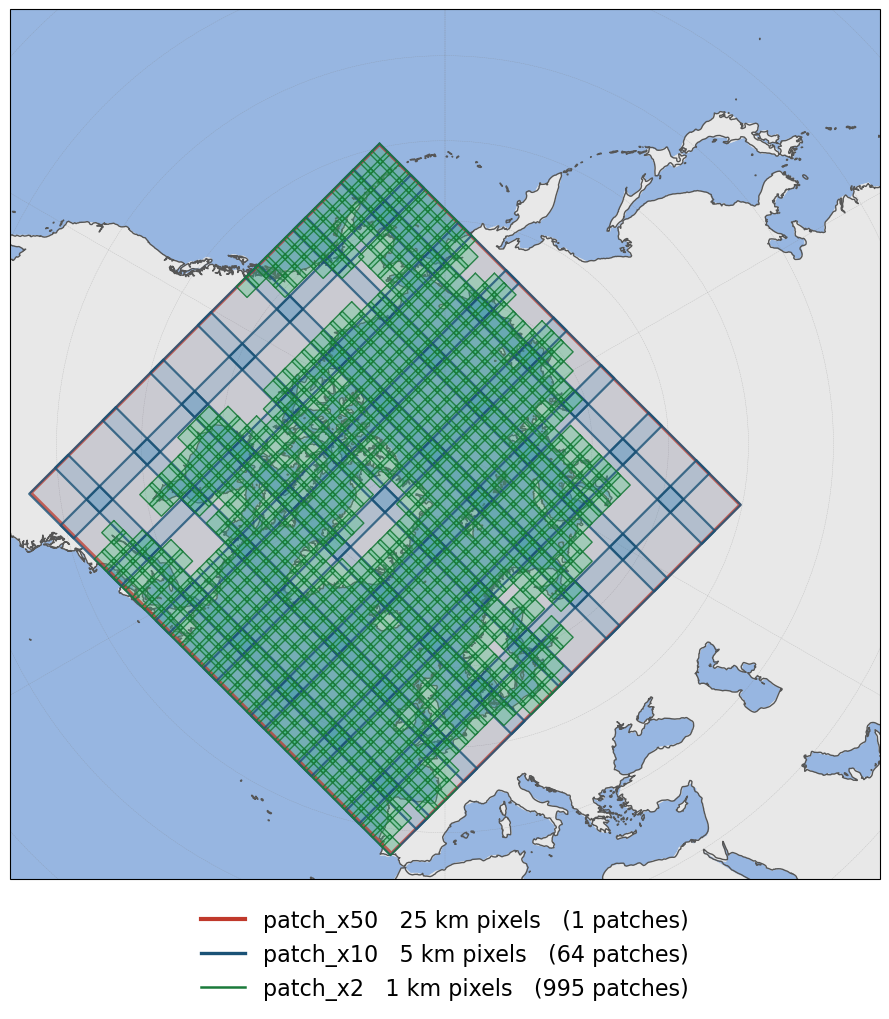

In [15]:

# ── Figure A: all three resolutions overlaid ─────────────────────────────────
from matplotlib.patches import Polygon as MplPolygon

map_proj = ccrs.NorthPolarStereo()
map_proj._threshold /= 100.

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(projection=map_proj))
_setup_arctic_ax(ax, lat_min=lat_min_x50, lat_max=lat_max_x50)

for key in RES_KEYS:
    s = STYLES[key]
    for c in all_coords[key]:
        px_arr, py_arr = patch_corners_projected(c.lon.data, c.lat.data)
        xy = np.column_stack([px_arr[:-1], py_arr[:-1]])
        ax.add_patch(MplPolygon(xy, closed=True,
                                facecolor=s['facecolor'], alpha=s['alpha_face'],
                                edgecolor='none', zorder=3))
        ax.plot(px_arr, py_arr,
                color=s['edgecolor'], lw=s['lw'], alpha=s['alpha_edge'],
                solid_capstyle='round', solid_joinstyle='round', zorder=4)

fig.legend(handles=make_legend_handles(all_coords),
           loc='lower center', bbox_to_anchor=(0.5, -0.14),
           ncol=1, fontsize=16, framealpha=0., edgecolor='#aaa')
plt.tight_layout()
plt.show()


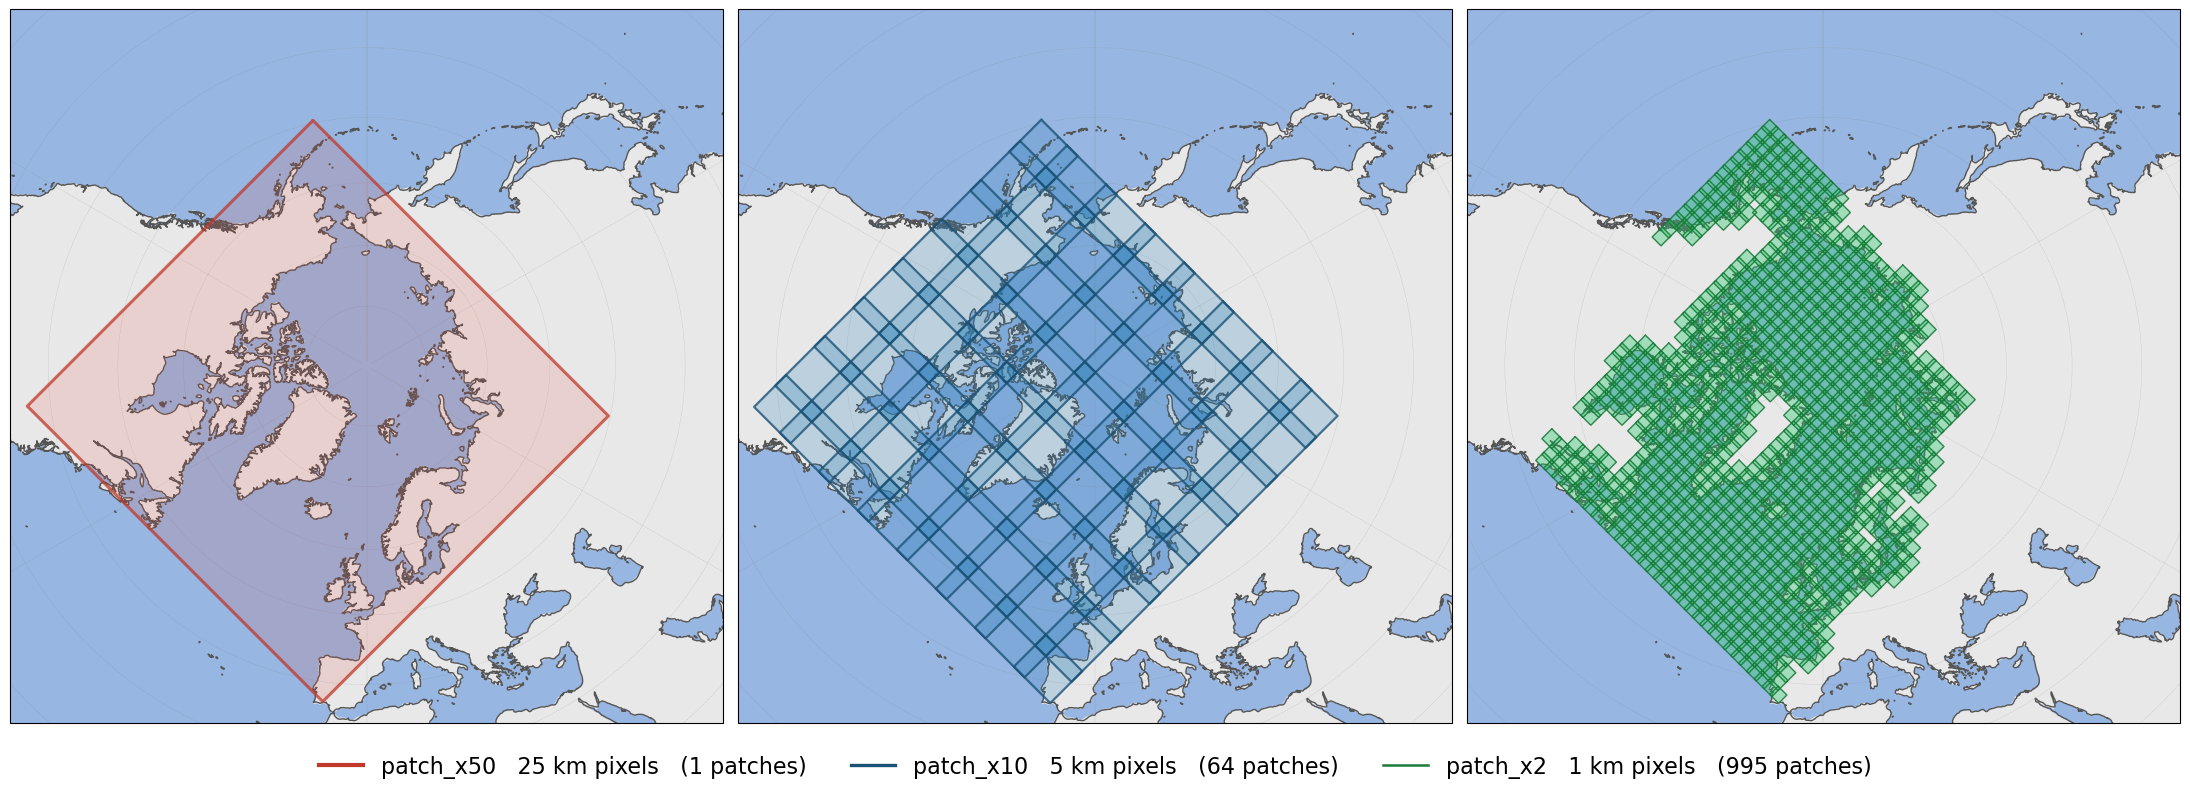

In [16]:

# ── Figure B: side-by-side — one panel per resolution ────────────────────────

map_proj3 = ccrs.NorthPolarStereo()
map_proj3._threshold /= 100.

fig3, axes3 = plt.subplots(1, 3, figsize=(22, 8),
                            subplot_kw=dict(projection=map_proj3))

for ax3, key in zip(axes3, RES_KEYS):
    s = STYLES[key]
    _setup_arctic_ax(ax3, lat_min=lat_min_x50, lat_max=lat_max_x50)

    for c in all_coords[key]:
        px_arr, py_arr = patch_corners_projected(c.lon.data, c.lat.data)
        xy = np.column_stack([px_arr[:-1], py_arr[:-1]])
        ax3.add_patch(MplPolygon(xy, closed=True,
                                 facecolor=s['facecolor'], alpha=s['alpha_face'] * 1.5,
                                 edgecolor='none', zorder=3))
        ax3.plot(px_arr, py_arr,
                 color=s['edgecolor'], lw=s['lw'], alpha=s['alpha_edge'],
                 solid_capstyle='round', solid_joinstyle='round', zorder=4)

fig3.legend(handles=make_legend_handles(all_coords),
            loc='lower center', bbox_to_anchor=(0.5, -0.04),
            ncol=3, fontsize=16, framealpha=0., edgecolor='#aaa')
plt.tight_layout()
plt.show()


---
## 7️⃣ Graph layer — hierarchical inter-patch interaction diagram

3-D "stacked layers" view showing:
- Each patch as a node (coloured by resolution)
- **Parent → child edges** between adjacent resolutions (nearest-neighbour in projected space)
- **Lateral edges** between neighbouring patches within the same resolution

This illustrates the planned **graph super-layer** that sits on top of the three
convolutional encoders and lets embeddings propagate across scales and space.


In [17]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
from scipy.spatial import cKDTree
import cartopy.crs as ccrs

# ── 1. Compute patch centroids in NPS metres ──────────────────────────────────
_NPS = ccrs.NorthPolarStereo()
_GEO = ccrs.Geodetic()

def patch_centroid_nps(c):
    lon_c = float(c.lon.data.mean())
    lat_c = float(c.lat.data.mean())
    pt = _NPS.transform_point(lon_c, lat_c, _GEO)
    return pt[0], pt[1]

centroids = {}
for key in RES_KEYS:
    centroids[key] = np.array([patch_centroid_nps(c) for c in all_coords[key]])

# Normalise to [0,1] using shared bounding box
all_xy = np.vstack(list(centroids.values()))
xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)
span = max(xmax - xmin, ymax - ymin)

def norm(xy):
    return (xy - np.array([xmin, ymin])) / span

norm_cents = {k: norm(v) for k, v in centroids.items()}

# ── 2. Layer altitudes ────────────────────────────────────────────────────────
Z_LAYER = {'patch_x50': 2.0, 'patch_x10': 1.0, 'patch_x2': 0.0}

# ── 3. Build edges ────────────────────────────────────────────────────────────
K_HIER  = 3   # each fine patch connects to K nearest coarse patches
K_LATER = 3   # lateral: K nearest same-level neighbours

def build_edges_hier(coarse_xy, fine_xy, k=K_HIER):
    """fine → k nearest coarse patches (query fine positions in coarse tree)."""
    k_eff = min(k, len(coarse_xy))
    tree  = cKDTree(coarse_xy)
    _, idxs = tree.query(fine_xy, k=k_eff)
    if idxs.ndim == 1:
        idxs = idxs[:, None]
    edges = []
    for fi, row in enumerate(idxs):
        for ci in np.atleast_1d(row):
            edges.append((int(ci), int(fi)))
    return edges

def build_edges_lateral(xy, k=K_LATER):
    """k nearest same-level neighbours, deduplicated."""
    if len(xy) < 2:
        return []
    k_eff = min(k + 1, len(xy))
    tree  = cKDTree(xy)
    _, idxs = tree.query(xy, k=k_eff)
    seen, edges = set(), []
    for i, row in enumerate(idxs):
        for j in row:
            if j == i:
                continue
            pair = (min(i, j), max(i, j))
            if pair not in seen:
                seen.add(pair)
                edges.append(pair)
    return edges

edges_50_10  = build_edges_hier(norm_cents['patch_x50'], norm_cents['patch_x10'], k=K_HIER)
edges_10_2   = build_edges_hier(norm_cents['patch_x10'], norm_cents['patch_x2'],  k=K_HIER)
edges_lat_50 = build_edges_lateral(norm_cents['patch_x50'], k=K_LATER)
edges_lat_10 = build_edges_lateral(norm_cents['patch_x10'], k=K_LATER)
edges_lat_2  = build_edges_lateral(norm_cents['patch_x2'],  k=K_LATER)

print(f"Patch counts  x50={len(norm_cents['patch_x50'])}  x10={len(norm_cents['patch_x10'])}  x2={len(norm_cents['patch_x2'])}")
print(f"Hierarchical edges  x50→x10 : {len(edges_50_10)}")
print(f"Hierarchical edges  x10→x2  : {len(edges_10_2)}")
print(f"Lateral edges       x50      : {len(edges_lat_50)}")
print(f"Lateral edges       x10      : {len(edges_lat_10)}")
print(f"Lateral edges       x2       : {len(edges_lat_2)}")


Patch counts  x50=1  x10=64  x2=995
Hierarchical edges  x50→x10 : 64
Hierarchical edges  x10→x2  : 2985
Lateral edges       x50      : 0
Lateral edges       x10      : 108
Lateral edges       x2       : 1853


Rendering layer textures… done.
 done.


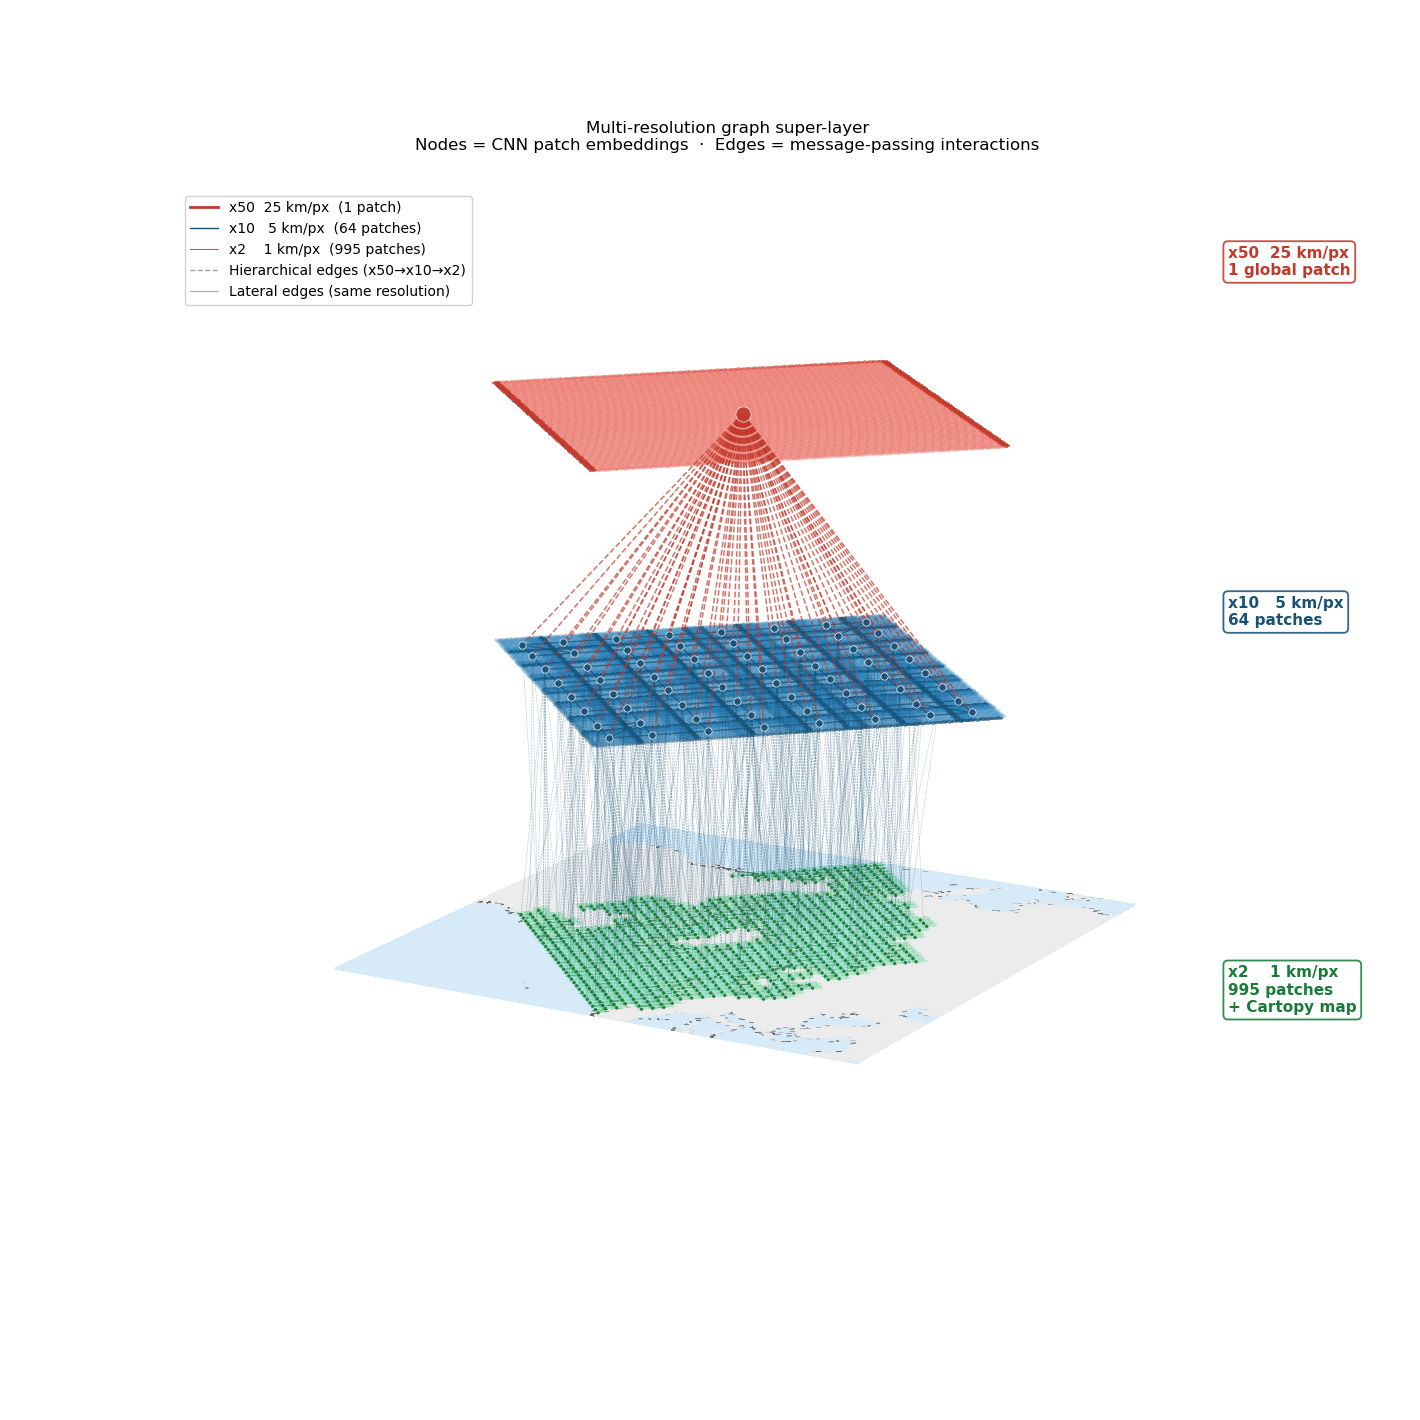

Saved → graph_layer_3d_flat.png


In [19]:

# ── 4.  3-D flat-stacked graph view ──────────────────────────────────────────
#
#  Three horizontal planes at different heights:
#    z=0  → x2  : one Cartopy Arctic map as texture + 2-D patch polygons drawn
#                  exactly like Figure A (filled + outlined) + centroid nodes
#    z=1  → x10 : plain dark plane + patch polygons + centroid nodes
#    z=2  → x50 : plain dark plane + patch polygon  + centroid node
#
#  Hierarchical edges connect centroid nodes between adjacent layers.
#  Lateral edges connect neighbouring centroid nodes within each layer.
#
#  Colours match the 2-D figures: red=x50, blue=x10, green=x2.
#  Edges/nodes drawn in a 2-D display-space overlay to avoid matplotlib-3D
#  z-ordering bugs (surfaces always occlude Line3DCollection).
# ─────────────────────────────────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════════════════════
#  ★  VIEW PARAMETERS — tune these to adjust the 3-D perspective  ★
# ══════════════════════════════════════════════════════════════════════════════
ELEV        = 15      # Elevation angle (°): higher → more top-down view
AZIM        = -60     # Azimuth angle (°):   rotate around vertical axis
FIG_SIZE    = (14, 14)  # Figure size in inches

# Vertical spacing between the three planes (in scene units)
# Decrease to bring planes closer together
Z_LAYER = {'patch_x2': 0.0, 'patch_x10': 0.8, 'patch_x50': 1.6}

# Box aspect ratio [x_scale, y_scale, z_scale] — controls how stretched
# the Z axis appears relative to X/Y
BOX_ASPECT  = [1, 1, Z_LAYER['patch_x50'] * 0.6]
# ══════════════════════════════════════════════════════════════════════════════

import io, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.lines as mlines, matplotlib.image as mpimg
import matplotlib.transforms as mtransforms
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import Axes3D, proj3d
from scipy.spatial import cKDTree
from scipy.ndimage import map_coordinates
import cartopy.crs as ccrs, cartopy.feature as cfeature

_NPS = ccrs.NorthPolarStereo(); _GEO = ccrs.Geodetic()

# ── A. NPS bounding box (shared across all resolutions) ───────────────────────
all_px, all_py = [], []
for key in RES_KEYS:
    for c in all_coords[key]:
        px, py = patch_corners_projected(c.lon.data, c.lat.data)
        all_px.extend(px.tolist()); all_py.extend(py.tolist())
MAP_XMIN, MAP_XMAX = min(all_px), max(all_px)
MAP_YMIN, MAP_YMAX = min(all_py), max(all_py)

def to01(px, py):
    """NPS metres → [0,1]²."""
    u = (np.asarray(px) - MAP_XMIN) / (MAP_XMAX - MAP_XMIN)
    v = (np.asarray(py) - MAP_YMIN) / (MAP_YMAX - MAP_YMIN)
    return u, v

def centroid01(c):
    pxa, pya = patch_corners_projected(c.lon.data, c.lat.data)
    u, v = to01(np.mean(pxa[:-1]), np.mean(pya[:-1]))
    return float(u), float(v)

# Patch centroid positions in [0,1]²
cents01 = {k: np.array([centroid01(c) for c in all_coords[k]]) for k in RES_KEYS}

# ── B. Edge builders (same as cell 21) ────────────────────────────────────────
def build_hier(coarse, fine, k=3):
    k_eff = min(k, len(coarse))
    _, idx = cKDTree(coarse).query(fine, k=k_eff)
    if idx.ndim == 1: idx = idx[:, None]
    return [(int(ci), int(fi)) for fi, row in enumerate(idx)
            for ci in np.atleast_1d(row)]

def build_lat(xy, k=3):
    if len(xy) < 2: return []
    _, idx = cKDTree(xy).query(xy, k=min(k + 1, len(xy)))
    seen, out = set(), []
    for i, row in enumerate(idx):
        for j in row:
            if j == i: continue
            p = (min(i, j), max(i, j))
            if p not in seen: seen.add(p); out.append(p)
    return out

rng = np.random.default_rng(42)
def sub(e, n):
    return [e[i] for i in rng.choice(len(e), n, replace=False)] \
           if n and len(e) > n else e

e_50_10  = build_hier(cents01['patch_x50'], cents01['patch_x10'])
e_10_2   = sub(build_hier(cents01['patch_x10'], cents01['patch_x2']), 500)
e_lat_50 = build_lat(cents01['patch_x50'])
e_lat_10 = build_lat(cents01['patch_x10'])
e_lat_2  = sub(build_lat(cents01['patch_x2']), 350)

# ── C. Render Cartopy map textures ────────────────────────────────────────────
TEX_PX = 2048

PATCH_ST = {
    'patch_x50': dict(fc='#e74c3c', af=0.12, ec='#c0392b', lw=6.0, ae=0.85),
    'patch_x10': dict(fc='#2980b9', af=0.18, ec='#1a5276', lw=4.0, ae=0.88),
    'patch_x2':  dict(fc='#2ecc71', af=0.28, ec='#1a7a3a', lw=2.0, ae=0.92),
}

def render_layer_rgba(key, px=TEX_PX, with_map=True):
    """Render one resolution layer as an RGBA PNG array."""
    dpi = 100; sz = px / dpi
    f, a = plt.subplots(1, 1, figsize=(sz, sz), dpi=dpi,
                        subplot_kw=dict(projection=_NPS))
    a.set_extent([MAP_XMIN, MAP_XMAX, MAP_YMIN, MAP_YMAX], crs=_NPS)
    if with_map:
        a.add_feature(cfeature.OCEAN, zorder=0, color='#d6eaf8')
        a.add_feature(cfeature.LAND,  zorder=1, color='#ececec',
                      edgecolor='#999', linewidth=0.5)
        a.coastlines(resolution='10m', linewidth=0.8, zorder=2, color='#666')
    else:
        a.set_facecolor('#1a1a2e')
    s = PATCH_ST[key]
    for c in all_coords[key]:
        pxa, pya = patch_corners_projected(c.lon.data, c.lat.data)
        xy = np.column_stack([pxa[:-1], pya[:-1]])
        a.add_patch(MplPolygon(xy, closed=True, transform=_NPS,
                    facecolor=s['fc'], alpha=s['af'], edgecolor='none', zorder=3))
        a.plot(pxa, pya, transform=_NPS, color=s['ec'], lw=s['lw'],
               alpha=s['ae'], solid_capstyle='round', zorder=4)
    a.set_axis_off(); f.subplots_adjust(0, 0, 1, 1)
    buf = io.BytesIO()
    f.savefig(buf, format='png', dpi=dpi, bbox_inches='tight',
              pad_inches=0, transparent=True)
    plt.close(f); buf.seek(0)
    return mpimg.imread(buf)

print("Rendering layer textures…", end='', flush=True)
layer_imgs = {
    'patch_x2':  render_layer_rgba('patch_x2',  with_map=True),
    'patch_x10': render_layer_rgba('patch_x10', with_map=False),
    'patch_x50': render_layer_rgba('patch_x50', with_map=False),
}
print(" done.")

# ── D. Resample texture onto flat mesh ────────────────────────────────────────
N_U, N_V = 150, 150
ug = np.linspace(0, 1, N_U); vg = np.linspace(0, 1, N_V)
UU, VV = np.meshgrid(ug, vg)

def texture_on_mesh(img, nv, nu):
    H, W = img.shape[:2]
    u_px = np.linspace(0, W - 1, nu)
    v_px = np.linspace(H - 1, 0, nv)
    UP, VP = np.meshgrid(u_px, v_px)
    out = np.zeros((nv, nu, 4), dtype=np.float32)
    for ch in range(4):
        out[..., ch] = map_coordinates(img[..., ch],
                                       [VP.ravel(), UP.ravel()],
                                       order=1, mode='nearest').reshape(nv, nu)
    return np.clip(out, 0, 1)

# ── E. Figure: 3-D axes ───────────────────────────────────────────────────────
fig = plt.figure(figsize=FIG_SIZE)
fig.patch.set_facecolor('white')
ax3d = fig.add_subplot(111, projection='3d')
ax3d.set_proj_type('persp')
ax3d.view_init(elev=ELEV, azim=AZIM)

# Draw surfaces bottom → top
SURF_ALPHA = {'patch_x2': 0.95, 'patch_x10': 0.82, 'patch_x50': 0.78}
for key in ['patch_x2', 'patch_x10', 'patch_x50']:
    z = Z_LAYER[key]
    fc = texture_on_mesh(layer_imgs[key], N_V, N_U)
    fc[..., 3] *= SURF_ALPHA[key]
    ax3d.plot_surface(UU, VV, np.full_like(UU, z),
                      facecolors=fc, rstride=1, cstride=1,
                      antialiased=False, shade=False)

# Border frame — only on the x2 (bottom) layer
n_b = 60; t = np.linspace(0, 1, n_b)
z0 = np.zeros(n_b); z1 = np.ones(n_b)
z = Z_LAYER['patch_x2']
for bu, bv in [(t, z0), (t, z1), (z0, t), (z1, t)]:
    ax3d.plot(bu, bv, np.full(n_b, z), color='#1a7a3a', lw=1.0, alpha=0.60)

# ── F. Axis cosmetics — hide ALL spines, ticks, panes, grid ──────────────────
pad = 0.05
ax3d.set_xlim(-pad, 1 + pad)
ax3d.set_ylim(-pad, 1 + pad)
ax3d.set_zlim(-0.2, Z_LAYER['patch_x50'] + pad)
ax3d.set_box_aspect(BOX_ASPECT)

ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
ax3d.set_xlabel(''); ax3d.set_ylabel(''); ax3d.set_zlabel('')

# Remove all pane fills and edges
for pane in [ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('none')

# Hide the axis lines themselves
ax3d.xaxis.line.set_color('none')
ax3d.yaxis.line.set_color('none')
ax3d.zaxis.line.set_color('none')

ax3d.grid(False)
ax3d.set_title('Multi-resolution graph super-layer\n'
               'Nodes = CNN patch embeddings  ·  Edges = message-passing interactions',
               fontsize=12, pad=20)

# Force draw → populate projection matrix
fig.canvas.draw()

# ── G. 3-D → display pixel helpers ───────────────────────────────────────────
def proj_pt(x, y, z):
    """3-D world (x=u, y=v, z=layer_height) → display pixels."""
    xd, yd, _ = proj3d.proj_transform(x, y, z, ax3d.get_proj())
    return ax3d.transData.transform((xd, yd))

def node_disp(key, uv):
    u, v = float(uv[0]), float(uv[1])
    return proj_pt(u, v, Z_LAYER[key])

# ── H. Full-figure 2-D overlay ────────────────────────────────────────────────
FW = fig.get_figwidth()  * fig.dpi
FH = fig.get_figheight() * fig.dpi
ax2d = fig.add_axes([0, 0, 1, 1], facecolor='none', zorder=5)
ax2d.set_xlim(0, FW); ax2d.set_ylim(0, FH); ax2d.set_axis_off()

def draw_lc(segs, col, lw, al, ls='-', zo=6):
    if segs:
        ax2d.add_collection(LineCollection(segs, colors=col, linewidths=lw,
                                           alpha=al, linestyle=ls, zorder=zo))

def lat_segs(edges, key):
    return [[node_disp(key, cents01[key][i]),
             node_disp(key, cents01[key][j])] for i, j in edges]

def hier_segs(edges, src_key, dst_key):
    return [[node_disp(src_key, cents01[src_key][ci]),
             node_disp(dst_key, cents01[dst_key][fi])] for ci, fi in edges]

draw_lc(lat_segs(e_lat_2,  'patch_x2'),  '#1a7a3a', 0.5, 0.55)
draw_lc(lat_segs(e_lat_10, 'patch_x10'), '#1a5276', 1.0, 0.72)
draw_lc(lat_segs(e_lat_50, 'patch_x50'), '#c0392b', 2.0, 0.90)
draw_lc(hier_segs(e_10_2,  'patch_x10', 'patch_x2'),  '#1a5276', 0.4, 0.35, '--')
draw_lc(hier_segs(e_50_10, 'patch_x50', 'patch_x10'), '#c0392b', 1.1, 0.70, '--')

# ── I. Nodes (centroid dots) ──────────────────────────────────────────────────
NODE_ST = {
    'patch_x50': ('#c0392b', 120, 'white'),
    'patch_x10': ('#1a5276',  28, 'white'),
    'patch_x2':  ('#1a7a3a',   6, None),
}
for key in RES_KEYS:
    col, sz, ec = NODE_ST[key]
    pts = np.array([node_disp(key, uv) for uv in cents01[key]])
    kw = dict(c=col, s=sz, linewidths=0.5 if ec else 0,
              edgecolors=ec or 'none', alpha=0.92, zorder=8)
    ax2d.scatter(pts[:, 0], pts[:, 1], **kw)

# ── J. Legend + layer labels ──────────────────────────────────────────────────
legend_handles = [
    mlines.Line2D([], [], color='#c0392b', lw=2.0,
                  label=f'x50  25 km/px  (1 patch)'),
    mlines.Line2D([], [], color='#1a5276', lw=1.0,
                  label=f'x10   5 km/px  ({len(cents01["patch_x10"])} patches)'),
    mlines.Line2D([], [], color='#1a7a3a', lw=0.6,
                  label=f'x2    1 km/px  ({len(cents01["patch_x2"])} patches)'),
    mlines.Line2D([], [], color='#888', lw=1.0, linestyle='--', alpha=0.8,
                  label='Hierarchical edges (x50→x10→x2)'),
    mlines.Line2D([], [], color='#888', lw=0.8, alpha=0.7,
                  label='Lateral edges (same resolution)'),
]
ax3d.legend(handles=legend_handles, loc='upper left',
            bbox_to_anchor=(-0.01, 0.99), fontsize=10, framealpha=0.88)

for fx, fy, txt, col in [
    (0.87, 0.82, 'x50  25 km/px\n1 global patch',  '#c0392b'),
    (0.87, 0.57, 'x10   5 km/px\n64 patches',       '#1a5276'),
    (0.87, 0.30, 'x2    1 km/px\n995 patches\n+ Cartopy map', '#1a7a3a'),
]:
    fig.text(fx, fy, txt, fontsize=11, color=col, fontweight='bold',
             ha='left', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor=col, alpha=0.88, linewidth=1.3))

plt.savefig('graph_layer_3d_flat.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved → graph_layer_3d_flat.png")


---
## Summary

| Resolution | Pixel spacing | Spatial coverage per patch | Use in model |
|------------|--------------|---------------------------|---------------|
| `patch_x50` | 25 km | ~7 350 × 7 600 km | Low-res context (coarse SIT/SIC) |
| `patch_x10` |  5 km | ~1 280 × 1 280 km | Medium-res interpolation |
| `patch_x2`  |  1 km |  ~256 × 256 km   | High-res target (ASIP SIC) |

Each batch is a **nested triplet**: the x10 patch covers the same geographical centre
as the x2 patch but at coarser spacing, and x50 covers the full surrounding context.
This allows the model to fuse information across scales when reconstructing the
high-resolution target.